In [1]:
# ==========================================
# STEP 1: LOAD METADATA
# ==========================================

import pandas as pd

print("="*60)
print("[INFO] Loading metadata...")
print("="*60)

df = pd.read_csv("../data/raw/HAM10000_metadata.csv")

print("[SUCCESS] Metadata loaded successfully.")
print(f"[INFO] Dataset shape: {df.shape}")

print("="*60)

[INFO] Loading metadata...
[SUCCESS] Metadata loaded successfully.
[INFO] Dataset shape: (10015, 7)


In [2]:
# ==========================================
# STEP 2: HANDLE MISSING VALUES
# ==========================================

print("=" * 60)
print("[INFO] Handling missing values...")
print("=" * 60)

missing_before = df["age"].isnull().sum()

print(f"[INFO] Missing values before: {missing_before}")

median_age = df["age"].median()

print(f"[INFO] Median age: {median_age}")

df["age"] = df["age"].fillna(median_age)

missing_after = df["age"].isnull().sum()

print(f"[INFO] Missing values after: {missing_after}")

print("=" * 60)
print("[SUCCESS] Missing values handled successfully.")
print("=" * 60)

[INFO] Handling missing values...
[INFO] Missing values before: 57
[INFO] Median age: 50.0
[INFO] Missing values after: 0
[SUCCESS] Missing values handled successfully.


In [3]:
# ==========================================
# OBSERVATION REPORT
# ==========================================

print("=" * 60)
print("[OBSERVATION REPORT]")
print("=" * 60)

print("[✓] 57 missing age values detected.")
print("[✓] Median imputation was used.")
print("[✓] No missing values remain.")
print("[✓] Dataset size was preserved.")

print("=" * 60)
print("[SUCCESS] Observation completed.")
print("=" * 60)

[OBSERVATION REPORT]
[✓] 57 missing age values detected.
[✓] Median imputation was used.
[✓] No missing values remain.
[✓] Dataset size was preserved.
[SUCCESS] Observation completed.


In [4]:
df.isnull().sum()

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dtype: int64

In [5]:
# ==========================================
# STEP 3: LABEL ENCODING
# ==========================================

from sklearn.preprocessing import LabelEncoder

print("=" * 60)
print("[INFO] Encoding target labels...")
print("=" * 60)

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["dx"])

print("[SUCCESS] Labels encoded successfully.")

print("\n[INFO] Label Mapping:")

for class_name, label in zip(label_encoder.classes_,
                             range(len(label_encoder.classes_))):
    print(f"{class_name:<10} → {label}")

print("=" * 60)

[INFO] Encoding target labels...
[SUCCESS] Labels encoded successfully.

[INFO] Label Mapping:
akiec      → 0
bcc        → 1
bkl        → 2
df         → 3
mel        → 4
nv         → 5
vasc       → 6


In [6]:
df[["dx", "label"]].head()

,dx,label
0,bkl,2
1,bkl,2
2,bkl,2
3,bkl,2
4,bkl,2


In [7]:
# ==========================================
# STEP 4: CREATE IMAGE PATHS
# ==========================================

from pathlib import Path

print("=" * 60)
print("[INFO] Creating image paths...")
print("=" * 60)

image_dir = Path("../data/images")

df["image_path"] = df["image_id"].apply(
    lambda x: str(image_dir / f"{x}.jpg")
)

print("[SUCCESS] Image paths created successfully.")

print("=" * 60)
print("[INFO] Sample paths:")
print("=" * 60)

print(df[["image_id", "image_path"]].head())

print("=" * 60)

[INFO] Creating image paths...
[SUCCESS] Image paths created successfully.
[INFO] Sample paths:
       image_id                       image_path
0  ISIC_0027419  ..\data\images\ISIC_0027419.jpg
1  ISIC_0025030  ..\data\images\ISIC_0025030.jpg
2  ISIC_0026769  ..\data\images\ISIC_0026769.jpg
3  ISIC_0025661  ..\data\images\ISIC_0025661.jpg
4  ISIC_0031633  ..\data\images\ISIC_0031633.jpg


In [8]:
# ==========================================
# OBSERVATION REPORT
# ==========================================

print("=" * 60)
print("[OBSERVATION REPORT]")
print("=" * 60)

print("[✓] Image paths created successfully.")
print("[✓] Each image now has a file location.")
print("[✓] Dataset is ready for PyTorch Dataset class.")

print("=" * 60)
print("[SUCCESS] Observation completed.")
print("=" * 60)

[OBSERVATION REPORT]
[✓] Image paths created successfully.
[✓] Each image now has a file location.
[✓] Dataset is ready for PyTorch Dataset class.
[SUCCESS] Observation completed.


In [9]:
# ==========================================
# STEP 5: VERIFY IMAGE FILES
# ==========================================

print("=" * 60)
print("[INFO] Verifying image files...")
print("=" * 60)

from pathlib import Path

df["image_exists"] = df["image_path"].apply(
    lambda x: Path(x).exists()
)

existing_images = df["image_exists"].sum()
missing_images = len(df) - existing_images

print(f"[INFO] Total Images      : {len(df)}")
print(f"[INFO] Existing Images   : {existing_images}")
print(f"[INFO] Missing Images    : {missing_images}")

print("=" * 60)

if missing_images == 0:
    print("[SUCCESS] All image files are present.")
else:
    print("[WARNING] Some images are missing!")

print("=" * 60)

[INFO] Verifying image files...
[INFO] Total Images      : 10015
[INFO] Existing Images   : 10015
[INFO] Missing Images    : 0
[SUCCESS] All image files are present.


In [10]:
# ==========================================
# OBSERVATION REPORT
# ==========================================

print("=" * 60)
print("[OBSERVATION REPORT]")
print("=" * 60)

print("[✓] All image paths were verified.")
print("[✓] Dataset integrity confirmed.")
print("[✓] Ready for train-validation-test split.")

print("=" * 60)
print("[SUCCESS] Observation completed.")
print("=" * 60)

[OBSERVATION REPORT]
[✓] All image paths were verified.
[✓] Dataset integrity confirmed.
[✓] Ready for train-validation-test split.
[SUCCESS] Observation completed.


# Step 6: Train Validation Test Split

Goal:
- Split dataset into train, validation and test sets.
- Preserve class distribution using stratification.

In [11]:
# ==========================================
# STEP 6.1: TRAIN / TEMPORARY SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

print("=" * 60)
print("[INFO] Creating training and temporary datasets...")
print("=" * 60)

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

print(f"[INFO] Training Samples  : {len(train_df)}")
print(f"[INFO] Temporary Samples : {len(temp_df)}")

print("=" * 60)
print("[SUCCESS] First split completed.")
print("=" * 60)

[INFO] Creating training and temporary datasets...
[INFO] Training Samples  : 7010
[INFO] Temporary Samples : 3005
[SUCCESS] First split completed.


In [12]:
# ==========================================
# OBSERVATION REPORT
# ==========================================

print("=" * 60)
print("[OBSERVATION REPORT]")
print("=" * 60)

print("[✓] 70% of the dataset allocated to training.")
print("[✓] Remaining 30% stored temporarily.")
print("[✓] Class distribution preserved using stratification.")
print("[✓] Temporary dataset will later be divided into validation and test sets.")

print("=" * 60)
print("[SUCCESS] Observation completed.")
print("=" * 60)

[OBSERVATION REPORT]
[✓] 70% of the dataset allocated to training.
[✓] Remaining 30% stored temporarily.
[✓] Class distribution preserved using stratification.
[✓] Temporary dataset will later be divided into validation and test sets.
[SUCCESS] Observation completed.


In [13]:
# ==========================================
# STEP 6.2: VALIDATION / TEST SPLIT
# ==========================================

print("=" * 60)
print("[INFO] Creating validation and test datasets...")
print("=" * 60)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print(f"[INFO] Training Samples   : {len(train_df)}")
print(f"[INFO] Validation Samples : {len(val_df)}")
print(f"[INFO] Test Samples       : {len(test_df)}")

print("=" * 60)
print("[SUCCESS] Dataset splitting completed.")
print("=" * 60)

[INFO] Creating validation and test datasets...
[INFO] Training Samples   : 7010
[INFO] Validation Samples : 1502
[INFO] Test Samples       : 1503
[SUCCESS] Dataset splitting completed.


In [14]:
# ==========================================
# OBSERVATION REPORT
# ==========================================

print("=" * 60)
print("[OBSERVATION REPORT]")
print("=" * 60)

print("[✓] Training set created (70%).")
print("[✓] Validation set created (15%).")
print("[✓] Test set created (15%).")
print("[✓] Class distribution preserved using stratification.")

print("=" * 60)
print("[SUCCESS] Observation completed.")
print("=" * 60)

[OBSERVATION REPORT]
[✓] Training set created (70%).
[✓] Validation set created (15%).
[✓] Test set created (15%).
[✓] Class distribution preserved using stratification.
[SUCCESS] Observation completed.


In [15]:
# ==========================================
# STEP 6.3: VERIFY CLASS DISTRIBUTION
# ==========================================

print("=" * 60)
print("[INFO] Checking class distribution...")
print("=" * 60)

print("\nTRAIN SET")
print(train_df["dx"].value_counts(normalize=True).round(3))

print("\nVALIDATION SET")
print(val_df["dx"].value_counts(normalize=True).round(3))

print("\nTEST SET")
print(test_df["dx"].value_counts(normalize=True).round(3))

print("\n" + "=" * 60)
print("[SUCCESS] Class distribution verification completed.")
print("=" * 60)

[INFO] Checking class distribution...

TRAIN SET
dx
nv       0.669
mel      0.111
bkl      0.110
bcc      0.051
akiec    0.033
vasc     0.014
df       0.012
Name: proportion, dtype: float64

VALIDATION SET
dx
nv       0.670
mel      0.111
bkl      0.110
bcc      0.051
akiec    0.033
vasc     0.014
df       0.011
Name: proportion, dtype: float64

TEST SET
dx
nv       0.669
mel      0.111
bkl      0.110
bcc      0.051
akiec    0.033
vasc     0.015
df       0.011
Name: proportion, dtype: float64

[SUCCESS] Class distribution verification completed.


# Step 7: Image Transformations

Goal:
- Resize images to 224×224.
- Apply data augmentation to training images.
- Normalize images using ImageNet statistics.

In [16]:
# ==========================================
# STEP 7: IMAGE TRANSFORMATIONS
# ==========================================

from torchvision import transforms

print("=" * 60)
print("[INFO] Creating image transformations...")
print("=" * 60)

# Training transformations
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# Validation/Test transformations
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = val_transform

print("[SUCCESS] Image transformations created successfully.")
print("=" * 60)

[INFO] Creating image transformations...
[SUCCESS] Image transformations created successfully.


In [17]:
# ==========================================
# OBSERVATION REPORT
# ==========================================

print("=" * 60)
print("[OBSERVATION REPORT]")
print("=" * 60)

print("[✓] Images resized to 224×224.")
print("[✓] Data augmentation enabled for training.")
print("[✓] Validation and test images remain unchanged.")
print("[✓] ImageNet normalization applied.")

print("=" * 60)
print("[SUCCESS] Observation completed.")
print("=" * 60)

[OBSERVATION REPORT]
[✓] Images resized to 224×224.
[✓] Data augmentation enabled for training.
[✓] Validation and test images remain unchanged.
[✓] ImageNet normalization applied.
[SUCCESS] Observation completed.


In [18]:
from torch.utils.data import Dataset
from PIL import Image

In [19]:
# ==========================================
# STEP 8: CUSTOM DATASET CLASS
# ==========================================

class HAM10000Dataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        # Image path
        image_path = self.dataframe.iloc[idx]["image_path"]

        # Label
        label = self.dataframe.iloc[idx]["label"]

        # Open image
        image = Image.open(image_path).convert("RGB")

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        return image, label

In [20]:
# ==========================================
# STEP 8.1: CREATE DATASET OBJECTS
# ==========================================

print("=" * 60)
print("[INFO] Creating dataset objects...")
print("=" * 60)

train_dataset = HAM10000Dataset(
    dataframe=train_df,
    transform=train_transform
)

val_dataset = HAM10000Dataset(
    dataframe=val_df,
    transform=val_transform
)

test_dataset = HAM10000Dataset(
    dataframe=test_df,
    transform=test_transform
)

print(f"[INFO] Training Images   : {len(train_dataset)}")
print(f"[INFO] Validation Images : {len(val_dataset)}")
print(f"[INFO] Test Images       : {len(test_dataset)}")

print("=" * 60)
print("[SUCCESS] Dataset objects created successfully.")
print("=" * 60)

[INFO] Creating dataset objects...
[INFO] Training Images   : 7010
[INFO] Validation Images : 1502
[INFO] Test Images       : 1503
[SUCCESS] Dataset objects created successfully.


In [21]:
# ==========================================
# STEP 9: TEST DATASET
# ==========================================

print("=" * 60)
print("[INFO] Testing dataset...")
print("=" * 60)

image, label = train_dataset[0]

print(f"[INFO] Image Shape : {image.shape}")
print(f"[INFO] Label       : {label}")

print("=" * 60)
print("[SUCCESS] Dataset test completed.")
print("=" * 60)

[INFO] Testing dataset...
[INFO] Image Shape : torch.Size([3, 224, 224])
[INFO] Label       : 5
[SUCCESS] Dataset test completed.


In [22]:
# ==========================================
# STEP 9.1: CREATE DATALOADERS
# ==========================================

from torch.utils.data import DataLoader
import torch

print("=" * 60)
print("[INFO] Creating DataLoaders...")
print("=" * 60)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,      # Windows + VS Code + Jupyter safe
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(f"[INFO] Number of training batches   : {len(train_loader)}")
print(f"[INFO] Number of validation batches : {len(val_loader)}")
print(f"[INFO] Number of test batches       : {len(test_loader)}")

print("=" * 60)
print("[SUCCESS] DataLoaders created successfully.")
print("=" * 60)

[INFO] Creating DataLoaders...
[INFO] Number of training batches   : 220
[INFO] Number of validation batches : 47
[INFO] Number of test batches       : 47
[SUCCESS] DataLoaders created successfully.


In [23]:
# ==========================================
# STEP 10: TEST DATALOADER
# ==========================================

print("=" * 60)
print("[INFO] Testing DataLoader...")
print("=" * 60)

images, labels = next(iter(train_loader))

print(f"[INFO] Images Shape : {images.shape}")
print(f"[INFO] Labels Shape : {labels.shape}")

print("=" * 60)
print("[SUCCESS] DataLoader test completed.")
print("=" * 60)

[INFO] Testing DataLoader...
[INFO] Images Shape : torch.Size([32, 3, 224, 224])
[INFO] Labels Shape : torch.Size([32])
[SUCCESS] DataLoader test completed.


In [24]:
# ==========================================
# STEP 11: COMPUTE CLASS WEIGHTS
# ==========================================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

print("=" * 60)
print("[INFO] Computing class weights...")
print("=" * 60)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

print("[INFO] Class Weights:")

for idx, weight in enumerate(class_weights):
    print(f"Class {idx} : {weight:.4f}")

print("=" * 60)
print("[SUCCESS] Class weights computed successfully.")
print("=" * 60)

[INFO] Computing class weights...
[INFO] Class Weights:
Class 0 : 4.3731
Class 1 : 2.7817
Class 2 : 1.3022
Class 3 : 12.3633
Class 4 : 1.2855
Class 5 : 0.2134
Class 6 : 10.1154
[SUCCESS] Class weights computed successfully.


[INFO] Visualizing a batch of images...


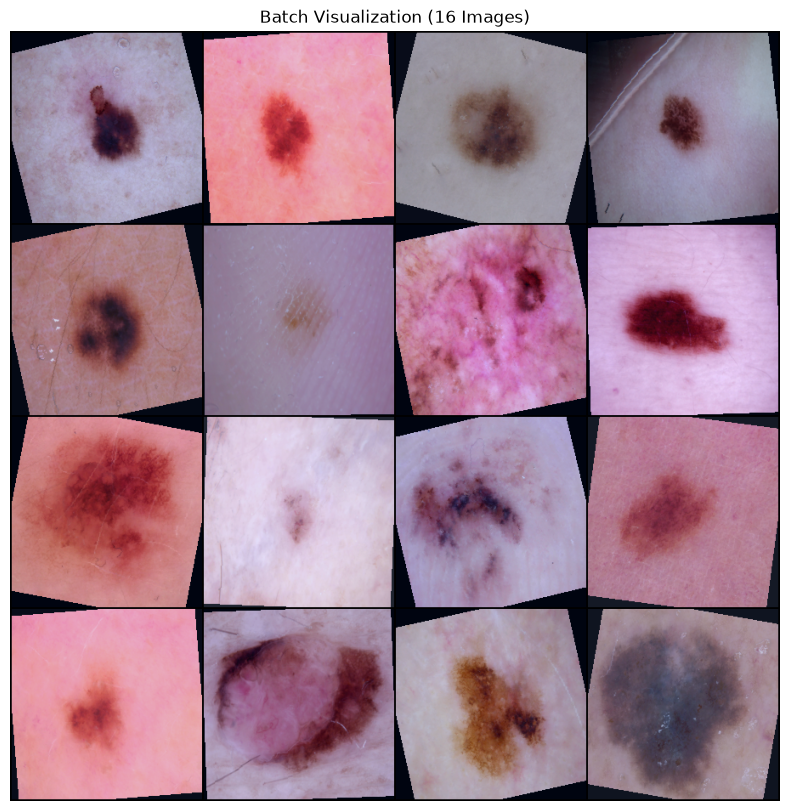

[SUCCESS] Batch visualization completed.


In [25]:
# ==========================================
# STEP 10.1: BATCH VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt
import torchvision

print("=" * 60)
print("[INFO] Visualizing a batch of images...")
print("=" * 60)

# Get one batch
images, labels = next(iter(train_loader))

# Create grid
grid = torchvision.utils.make_grid(
    images[:16],
    nrow=4,
    normalize=True
)

plt.figure(figsize=(10,10))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Batch Visualization (16 Images)")
plt.show()

print("[SUCCESS] Batch visualization completed.")
print("=" * 60)

In [26]:
# ==========================================
# OBSERVATION REPORT
# ==========================================

print("=" * 60)
print("[OBSERVATION REPORT]")
print("=" * 60)

print("[✓] Images loaded successfully.")
print("[✓] Data augmentation is working.")
print("[✓] Images are resized to 224×224.")
print("[✓] Batch generation verified.")

print("=" * 60)
print("[SUCCESS] Observation completed.")
print("=" * 60)

[OBSERVATION REPORT]
[✓] Images loaded successfully.
[✓] Data augmentation is working.
[✓] Images are resized to 224×224.
[✓] Batch generation verified.
[SUCCESS] Observation completed.


In [27]:
# ==========================================
# STEP 12: GPU SETUP
# ==========================================

import torch

print("=" * 60)
print("[INFO] Setting up device...")
print("=" * 60)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"[INFO] Device : {device}")

if torch.cuda.is_available():
    print(f"[INFO] GPU Name : {torch.cuda.get_device_name(0)}")

print("=" * 60)
print("[SUCCESS] Device setup completed.")
print("=" * 60)

[INFO] Setting up device...
[INFO] Device : cuda
[INFO] GPU Name : NVIDIA RTX A2000 Laptop GPU
[SUCCESS] Device setup completed.


In [2]:
# ==========================================
# STEP 13: DEFINE BASELINE CNN
# ==========================================

import torch.nn as nn

print("=" * 60)
print("[INFO] Creating Baseline CNN...")
print("=" * 60)

class BaselineCNN(nn.Module):

    def __init__(self):
        super().__init__()

        # Feature Extraction
        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        # Classification
        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(
                in_features=128 * 28 * 28,
                out_features=256
            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(
                in_features=256,
                out_features=7
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


print("[SUCCESS] Baseline CNN class created.")
print("=" * 60)

[INFO] Creating Baseline CNN...
[SUCCESS] Baseline CNN class created.


In [29]:
# ==========================================
# STEP 14: CREATE MODEL
# ==========================================

print("=" * 60)
print("[INFO] Creating model...")
print("=" * 60)

model = BaselineCNN().to(device)

print(model)

print("=" * 60)
print("[SUCCESS] Model moved to device.")
print("=" * 60)

# Count trainable parameters
total_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"[INFO] Total Trainable Parameters : {total_params:,}")

print("=" * 60)

[INFO] Creating model...
BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=7, bias=True)
  )
)
[SUCCESS] Model moved to device.
[INFO] Total Trainable Parameters : 25,785,415


In [30]:
# ==========================================
# STEP 15: LOSS FUNCTION
# ==========================================

import torch.nn as nn

print("=" * 60)
print("[INFO] Creating loss function...")
print("=" * 60)

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

print(criterion)

print("=" * 60)
print("[SUCCESS] Loss function created successfully.")
print("=" * 60)

[INFO] Creating loss function...
CrossEntropyLoss()
[SUCCESS] Loss function created successfully.


In [31]:
# ==========================================
# STEP 16: OPTIMIZER
# ==========================================

import torch.optim as optim

print("=" * 60)
print("[INFO] Creating optimizer...")
print("=" * 60)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print(optimizer)

print("=" * 60)
print("[SUCCESS] Optimizer created successfully.")
print("=" * 60)

[INFO] Creating optimizer...
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
[SUCCESS] Optimizer created successfully.


In [32]:
# ==========================================
# STEP 17: FORWARD PASS TEST
# ==========================================

print("=" * 60)
print("[INFO] Testing forward pass...")
print("=" * 60)

# Get one batch
images, labels = next(iter(train_loader))

# Move batch to GPU
images = images.to(device)
labels = labels.to(device)

# Forward pass
outputs = model(images)

print(f"[INFO] Input Shape  : {images.shape}")
print(f"[INFO] Output Shape : {outputs.shape}")

print("=" * 60)
print("[SUCCESS] Forward pass test completed.")
print("=" * 60)

[INFO] Testing forward pass...
[INFO] Input Shape  : torch.Size([32, 3, 224, 224])
[INFO] Output Shape : torch.Size([32, 7])
[SUCCESS] Forward pass test completed.


In [33]:
# ==========================================
# STEP 18A: TRAINING VARIABLES
# ==========================================

print("=" * 60)
print("[INFO] Initializing training variables...")
print("=" * 60)

# Number of epochs
num_epochs = 20

# History lists
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

# Best validation accuracy
best_val_accuracy = 0.0

print(f"[INFO] Number of epochs : {num_epochs}")

print("=" * 60)
print("[SUCCESS] Training variables initialized.")
print("=" * 60)

[INFO] Initializing training variables...
[INFO] Number of epochs : 20
[SUCCESS] Training variables initialized.


In [34]:
# ==========================================
# STEP 18B: IMPORT TQDM
# ==========================================

from tqdm import tqdm

print("=" * 60)
print("[INFO] tqdm imported successfully.")
print("=" * 60)

[INFO] tqdm imported successfully.


In [35]:
import os

os.makedirs("models", exist_ok=True)

In [36]:
# ==========================================
# STEP 18C: CREATE MODELS DIRECTORY
# ==========================================

import os

print("=" * 60)
print("[INFO] Creating models directory...")
print("=" * 60)

os.makedirs("models", exist_ok=True)

print("[SUCCESS] Models directory ready.")
print("=" * 60)

[INFO] Creating models directory...
[SUCCESS] Models directory ready.


In [37]:
# ==========================================
# STEP 18D: TRAINING LOOP
# ==========================================

print("=" * 60)
print("[INFO] Starting training...")
print("=" * 60)

for epoch in range(num_epochs):

    print(f"\n[INFO] Epoch {epoch+1}/{num_epochs}")

    # =========================
    # TRAINING
    # =========================
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc="Training"):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in tqdm(val_loader, desc="Validation"):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # =========================
    # SAVE BEST MODEL
    # =========================
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "models/baseline_cnn.pth"
        )

        print("[SUCCESS] Best model saved.")

    # =========================
    # LOGS
    # =========================
    print("-" * 60)
    print(f"Train Loss     : {train_loss:.4f}")
    print(f"Train Accuracy : {train_accuracy:.2f}%")
    print(f"Val Loss       : {val_loss:.4f}")
    print(f"Val Accuracy   : {val_accuracy:.2f}%")
    print("-" * 60)

print("=" * 60)
print("[SUCCESS] Training completed.")
print("=" * 60)

[INFO] Starting training...

[INFO] Epoch 1/20


Validation: 100%|██████████| 47/47 [00:37<00:00,  1.25it/s]


[SUCCESS] Best model saved.
------------------------------------------------------------
Train Loss     : 1.8732
Train Accuracy : 37.82%
Val Loss       : 1.7328
Val Accuracy   : 34.62%
------------------------------------------------------------

[INFO] Epoch 2/20


Validation: 100%|██████████| 47/47 [00:21<00:00,  2.20it/s]


[SUCCESS] Best model saved.
------------------------------------------------------------
Train Loss     : 1.6896
Train Accuracy : 42.68%
Val Loss       : 1.7198
Val Accuracy   : 59.85%
------------------------------------------------------------

[INFO] Epoch 3/20


...

------------------------------------------------------------
Train Loss     : 1.1852
Train Accuracy : 56.65%
Val Loss       : 1.3662
Val Accuracy   : 55.39%
------------------------------------------------------------

[INFO] Epoch 19/20


Validation: 100%|██████████| 47/47 [00:17<00:00,  2.62it/s]


------------------------------------------------------------
Train Loss     : 1.1766
Train Accuracy : 55.04%
Val Loss       : 1.3854
Val Accuracy   : 59.92%
------------------------------------------------------------

[INFO] Epoch 20/20


Validation: 100%|██████████| 47/47 [00:18<00:00,  2.60it/s]

------------------------------------------------------------
Train Loss     : 1.1760
Train Accuracy : 56.49%
Val Loss       : 1.3647
Val Accuracy   : 53.60%
------------------------------------------------------------
[SUCCESS] Training completed.


In [38]:
model.load_state_dict(
    torch.load("models/baseline_cnn.pth")
)

<All keys matched successfully>

In [39]:
# ==========================================
# STEP 20A: TEST EVALUATION
# ==========================================

print("=" * 60)
print("[INFO] Evaluating on test set...")
print("=" * 60)

model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in tqdm(test_loader, desc="Testing"):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_accuracy = 100 * test_correct / test_total

print("-" * 60)
print(f"[INFO] Test Accuracy : {test_accuracy:.2f}%")
print("-" * 60)

print("=" * 60)
print("[SUCCESS] Test evaluation completed.")
print("=" * 60)

[INFO] Evaluating on test set...


Testing: 100%|██████████| 47/47 [00:28<00:00,  1.68it/s]

------------------------------------------------------------
[INFO] Test Accuracy : 60.68%
------------------------------------------------------------
[SUCCESS] Test evaluation completed.


In [40]:
# ==========================================
# STEP 20B: COLLECT PREDICTIONS
# ==========================================

from tqdm import tqdm

print("=" * 60)
print("[INFO] Collecting predictions...")
print("=" * 60)

y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in tqdm(test_loader, desc="Predicting"):

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print("=" * 60)
print("[SUCCESS] Predictions collected successfully.")
print("=" * 60)

[INFO] Collecting predictions...


Predicting: 100%|██████████| 47/47 [00:18<00:00,  2.53it/s]

[SUCCESS] Predictions collected successfully.


[INFO] Creating confusion matrix...


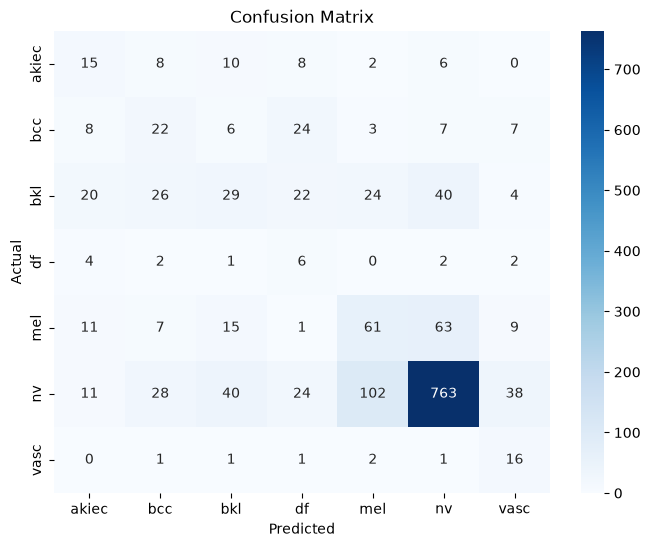

[SUCCESS] Confusion matrix created.


In [41]:
# ==========================================
# STEP 20C: CONFUSION MATRIX
# ==========================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("=" * 60)
print("[INFO] Creating confusion matrix...")
print("=" * 60)

# Class names
class_names = [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc"
]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

print("=" * 60)
print("[SUCCESS] Confusion matrix created.")
print("=" * 60)

In [42]:
# ==========================================
# STEP 20D: CLASSIFICATION REPORT
# ==========================================

from sklearn.metrics import classification_report

print("=" * 60)
print("[INFO] Classification Report")
print("=" * 60)

class_names = [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc"
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

print("=" * 60)
print("[SUCCESS] Classification report generated.")
print("=" * 60)

[INFO] Classification Report
              precision    recall  f1-score   support

       akiec       0.22      0.31      0.25        49
         bcc       0.23      0.29      0.26        77
         bkl       0.28      0.18      0.22       165
          df       0.07      0.35      0.12        17
         mel       0.31      0.37      0.34       167
          nv       0.87      0.76      0.81      1006
        vasc       0.21      0.73      0.33        22

    accuracy                           0.61      1503
   macro avg       0.31      0.42      0.33      1503
weighted avg       0.67      0.61      0.63      1503

[SUCCESS] Classification report generated.


In [43]:
print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=7, bias=True)
  )
)


In [1]:
import torch
import torch.nn as nn

In [6]:
from torchview import draw_graph

In [8]:
import os

os.environ["PATH"] += os.pathsep + r"D:\6thsemesterstudy\BDA LAb\Graphviz-12.2.1-win64\bin"

import shutil
print(shutil.which("dot"))

D:\6thsemesterstudy\BDA LAb\Graphviz-12.2.1-win64\bin\dot.EXE



(process:67136): Pango-WARNING **: 18:08:22.936: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.

(process:58028): Pango-WARNING **: 18:08:23.427: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


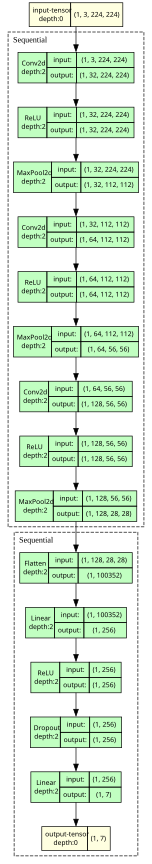

In [9]:
from torchview import draw_graph

graph = draw_graph(
    model,
    input_size=(1, 3, 224, 224),
    expand_nested=True,
    save_graph=True,
    filename="baseline_cnn"
)

graph.visual_graph